# 第二層（未調整版）：捕手 framing runs 與官方榜單對照

用第一層基準機率算每位捕手多偷/多丟的好球，換算成失分：

$$\text{extra strikes} = \sum (\text{實際判定} - \text{基準機率}), \qquad \text{framing runs} = \text{extra strikes} \times 0.125$$

再與 Baseball Savant 官方 framing 榜單（`rv_tot`）比相關性。

注意這是**對照**而非外部驗證：Savant 說明其 framing runs 含球場與投手調整，
完整模型未公開、對主審的處理也無文件說明；本版只控制位置與球數，兩種調整都沒做。
邏輯見 `models/framing_runs.py`、`data/official.py`。

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from models.framing_runs import load_baseline, framing_leaderboard, add_names, merge_official
from data.official import fetch_official_framing

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Arial Unicode MS', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

df = load_baseline(2023)
lb = add_names(framing_leaderboard(df))
print(f'{lb["mlbam_id"].n_unique()} 位捕手，共 {df.height:,} 顆判定球')

102 位捕手，共 351,094 顆判定球


## 我方 framing runs 排行榜

In [2]:
show = ['name','called_pitches','extra_strikes','framing_runs','framing_runs_per_1000']
qualified = lb.filter(pl.col('called_pitches') >= 2000)
print('=== 前 10（偷最多好球）===')
print(qualified.head(10).select(show))
print('\n=== 後 10（丟最多好球）===')
print(qualified.sort('framing_runs').head(10).select(show))

=== 前 10（偷最多好球）===
shape: (10, 5)
┌────────────────────┬────────────────┬───────────────┬──────────────┬───────────────────────┐
│ name               ┆ called_pitches ┆ extra_strikes ┆ framing_runs ┆ framing_runs_per_1000 │
│ ---                ┆ ---            ┆ ---           ┆ ---          ┆ ---                   │
│ str                ┆ u32            ┆ f64           ┆ f64          ┆ f64                   │
╞════════════════════╪════════════════╪═══════════════╪══════════════╪═══════════════════════╡
│ Bailey, Patrick    ┆ 6038           ┆ 141.68548     ┆ 17.710685    ┆ 2.933204              │
│ Hedges, Austin     ┆ 4865           ┆ 116.951169    ┆ 14.618896    ┆ 3.004912              │
│ Álvarez, Francisco ┆ 7430           ┆ 112.590754    ┆ 14.073844    ┆ 1.894192              │
│ Heim, Jonah        ┆ 7870           ┆ 91.561872     ┆ 11.445234    ┆ 1.454286              │
│ Contreras, William ┆ 7802           ┆ 85.842056     ┆ 10.730257    ┆ 1.375321              │
│ Rogers, Jake  

## 與官方榜單對照

與官方合格捕手 inner join，比 Pearson（線性）與 Spearman（排名）相關。

合格捕手 n = 63
Pearson  r = 0.990
Spearman r = 0.988


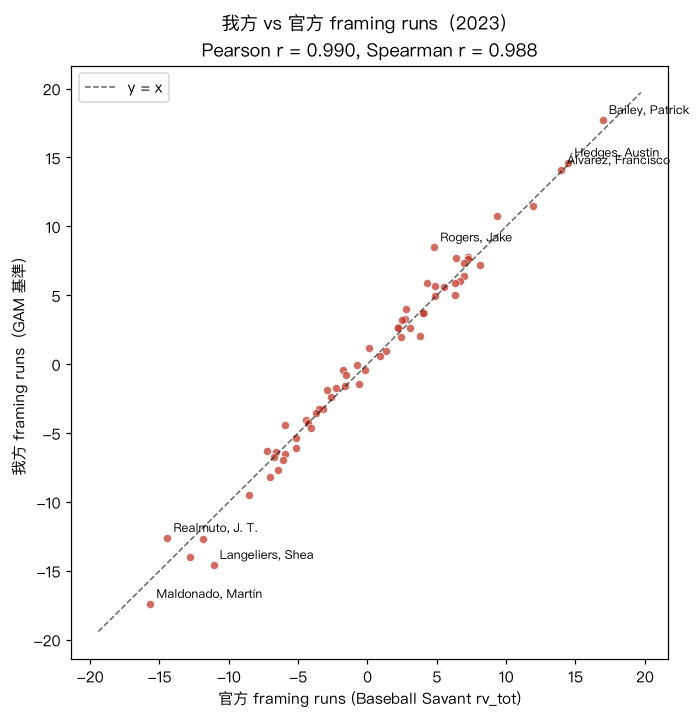

In [3]:
official = fetch_official_framing(2023)
merged = merge_official(lb, official)
x = merged['official_runs'].to_numpy()
y = merged['framing_runs'].to_numpy()
pr, _ = pearsonr(x, y); sr, _ = spearmanr(x, y)
print(f'合格捕手 n = {len(merged)}')
print(f'Pearson  r = {pr:.3f}')
print(f'Spearman r = {sr:.3f}')

fig, ax = plt.subplots(figsize=(7, 7))
lim = [min(x.min(), y.min()) - 2, max(x.max(), y.max()) + 2]
ax.plot(lim, lim, 'k--', lw=1, alpha=0.6, label='y = x')
ax.scatter(x, y, s=28, alpha=0.75, color='#c0392b', edgecolor='white', linewidth=0.5)
# 標註兩端與分歧最大者
merged = merged.with_columns(resid=(pl.col('framing_runs') - pl.col('official_runs')))
to_label = pl.concat([
    merged.sort('official_runs', descending=True).head(3),
    merged.sort('official_runs').head(2),
    merged.sort(pl.col('resid').abs(), descending=True).head(3),
]).unique(subset='mlbam_id')
for r in to_label.iter_rows(named=True):
    ax.annotate(r['name'], (r['official_runs'], r['framing_runs']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('官方 framing runs (Baseball Savant rv_tot)')
ax.set_ylabel('我方 framing runs（GAM 基準）')
ax.set_title(f'我方 vs 官方 framing runs（2023）\nPearson r = {pr:.3f}, Spearman r = {sr:.3f}')
ax.legend(loc='upper left')
fig.savefig('../figures/framing_vs_official_2023.png', bbox_inches='tight'); plt.show()

## 分歧最大的捕手

我方（未調整）與官方差距最大者。本版把捕手效應算成對基準的殘差總和，
會把「常配好投手/好主審場次」的殘差一併記到捕手頭上；官方則做了球場與投手調整。
兩邊的差異來源不只一個，不能單向解讀成某一方的偏差。

In [4]:
div = merged.select(['name','called_pitches','framing_runs','official_runs','resid']).sort(
    pl.col('resid').abs(), descending=True).head(8)
print(div)

shape: (8, 5)
┌────────────────────┬────────────────┬──────────────┬───────────────┬───────────┐
│ name               ┆ called_pitches ┆ framing_runs ┆ official_runs ┆ resid     │
│ ---                ┆ ---            ┆ ---          ┆ ---           ┆ ---       │
│ str                ┆ u32            ┆ f64          ┆ f64           ┆ f64       │
╞════════════════════╪════════════════╪══════════════╪═══════════════╪═══════════╡
│ Rogers, Jake       ┆ 6487           ┆ 8.467788     ┆ 4.80895       ┆ 3.658838  │
│ Langeliers, Shea   ┆ 9062           ┆ -14.577821   ┆ -11.095951    ┆ -3.48187  │
│ Realmuto, J. T.    ┆ 9250           ┆ -12.620113   ┆ -14.427871    ┆ 1.807758  │
│ Maldonado, Martín  ┆ 7891           ┆ -17.411188   ┆ -15.663245    ┆ -1.747943 │
│ Smith, Will        ┆ 7384           ┆ 2.043888     ┆ 3.776259      ┆ -1.732371 │
│ Rutschman, Adley   ┆ 7411           ┆ 5.873477     ┆ 4.265087      ┆ 1.608389  │
│ Gomes, Yan         ┆ 6682           ┆ -4.413092    ┆ -5.91528      ┆ 1.

## 觀察

- 未調整殘差榜單與官方榜單相關性極高（Pearson r ≈ 0.99），且前段班
  （Bailey / Hedges / Álvarez）與後段班都對得上。這說明第一層基準模型校準正確、
  失分換算合理，也順帶顯示官方的球場與投手調整不太改變榜單順序。
- 但它**不能**佐證這些就是捕手效應：本版沒有控制主審與投手，官方的完整模型也未公開。
  相關性高只代表兩者量到的東西高度重疊，不代表任一方分離出了捕手的真實技術。
- 下一步階層模型把主審、投手效應一起放進來互相競爭，並提供 shrinkage。